# Configs

In [ ]:
S3_OUTPUT_PATH = "renate_experiments/benchmarking"
AWS_ACCOUNT_ID = "536276317016"
NUM_SEEDS = 3
UPDATERS = ["er", "finetuning", "joint"]
UPDATER_LABELS = {
    "er": "Experience Replay",
    #"gdumb": "GDumb",
    "finetuning": "Fine-Tuning",
    "joint": "Joint",
}
BENCHMARK_TYPE = "class-incremental"
BENCHMARK = "cifar10-resnet18"

# Definitions

In [3]:
import json
from pathlib import Path
import tempfile
import shutil
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
  
from renate.benchmark.experimentation import execute_experiment_job, experiment_config_file
from renate.utils.file import maybe_download_from_s3


def submit_experiment(benchmark_type, benchmark, updater, num_seeds):
    benchmark_path = Path("benchmarking_configs") / benchmark_type / benchmark
    with open(benchmark_path / "scenario.json") as f:
        config_space = json.load(f)
    with open(benchmark_path / f"{updater}.json") as f:
        config_space.update(json.load(f))
    num_tasks = config_space["num_tasks"]
    del config_space["num_tasks"]
    for seed in range(num_seeds):
        execute_experiment_job(
            backend="sagemaker",
            config_file=experiment_config_file(),
            config_space=config_space,
            experiment_outputs_url=f"s3://sagemaker-us-west-2-{AWS_ACCOUNT_ID}/{S3_OUTPUT_PATH}/{benchmark_type}-{benchmark}-{updater}/{seed}",
            mode="max",
            metric="val_accuracy",
            num_updates=num_tasks,
            role=f"arn:aws:iam::{AWS_ACCOUNT_ID}:role/AmazonSageMakerServiceCatalogProductsUseRole",
            instance_type="ml.g4dn.xlarge",
            max_time=12 * 3600,
            n_workers=1,
            seed=seed,
            job_name=f"{benchmark}-{updater}-{seed}",
        )
        
def load_experiment_results(result_uri, num_tasks):
    assert num_tasks is not None
    tmp_dir = tempfile.mkdtemp()
    print(f"{result_uri}/logs")
    uri = maybe_download_from_s3(f"{result_uri}/logs", tmp_dir)
    results = pd.read_csv(Path(uri) / "metrics_summary.csv")
    uri = maybe_download_from_s3(f"{result_uri}/update_{num_tasks-1}", tmp_dir)
    hpo = pd.read_csv(Path(uri) / "hpo.csv")
    results["time"] = np.cumsum(hpo.groupby(["update_id"])["st_tuner_time"].max())
    shutil.rmtree(tmp_dir)
    return results

def get_results(num_tasks):
    final_results = {}
    for updater in UPDATERS:
        results = []
        for seed in range(NUM_SEEDS):
            results.append(
                load_experiment_results(
                    f"s3://sagemaker-us-west-2-{AWS_ACCOUNT_ID}/{S3_OUTPUT_PATH}/{BENCHMARK_TYPE}-{BENCHMARK}-{updater}/{seed}",
                    num_tasks=num_tasks
                )
            )
        acc_results = [list(r["Average Accuracy"]) for r in results]
        time_results = [list(r["time"]) for r in results]
        final_results[updater] = {
            "mean": np.mean(acc_results, axis=0),
            "std": np.std(acc_results, axis=0),
            "min": np.min(acc_results, axis=0),
            "max": np.max(acc_results, axis=0),
            "mean_time": np.mean(time_results, axis=0),
        }
    return final_results

def get_num_tasks(benchmark_type, benchmark):
    benchmark_path = Path("benchmarking_configs") / benchmark_type / benchmark
    with open(benchmark_path / "scenario.json") as f:
        config_space = json.load(f)
    return config_space["num_tasks"]

def submit_rotation_experiment(benchmark_type, benchmark, updater, num_seeds, max_degree):
    benchmark_path = Path("benchmarking_configs") / benchmark_type / benchmark
    with open(benchmark_path / "scenario.json") as f:
        config_space = json.load(f)
    with open(benchmark_path / f"{updater}.json") as f:
        config_space.update(json.load(f))
    num_tasks = config_space["num_tasks"]
    del config_space["num_tasks"]
    assert benchmark_type == "domain-incremental"
    degrees_key = "data_module_fn_degrees"
    assert degrees_key in config_space
    config_space[degrees_key] = "[" + (",".join([str(int(d)) for d in np.arange(0, max_degree, max_degree / num_tasks)])) + "]"
    for seed in range(num_seeds):
        execute_experiment_job(
            backend="sagemaker",
            config_file=experiment_config_file(),
            config_space=config_space,
            experiment_outputs_url=f"s3://sagemaker-us-west-2-{AWS_ACCOUNT_ID}/{S3_OUTPUT_PATH}/{benchmark_type}-{benchmark}-{updater}-{max_degree}/{seed}",
            mode="max",
            metric="val_accuracy",
            num_updates=num_tasks,
            role=f"arn:aws:iam::{AWS_ACCOUNT_ID}:role/AmazonSageMakerServiceCatalogProductsUseRole",
            instance_type="ml.g4dn.xlarge",
            max_time=12 * 3600,
            n_workers=1,
            seed=seed,
            job_name=f"{benchmark}-{updater}-{seed}",
        )
        
def get_rotation_results(num_tasks, max_degree):
    final_results = {}
    for updater in UPDATERS:
        results = []
        for seed in range(NUM_SEEDS):
            results.append(
                load_experiment_results(
                    f"s3://sagemaker-us-west-2-{AWS_ACCOUNT_ID}/{S3_OUTPUT_PATH}/{BENCHMARK_TYPE}-{BENCHMARK}-{updater}-{max_degree}/{seed}",
                    num_tasks=num_tasks
                )
            )
        acc_results = [list(r["Average Accuracy"]) for r in results]
        time_results = [list(r["time"]) for r in results]
        final_results[updater] = {
            "mean": np.mean(acc_results, axis=0),
            "std": np.std(acc_results, axis=0),
            "min": np.min(acc_results, axis=0),
            "max": np.max(acc_results, axis=0),
            "mean_time": np.mean(time_results, axis=0),
        }
    return final_results

# Submit Jobs

In [ ]:
for updater in UPDATERS:
    for max_degree in [5, 10, 15, 20, 45, 60, 75, 90, 120, 150]:
        submit_rotation_experiment(BENCHMARK_TYPE, BENCHMARK, updater, NUM_SEEDS, max_degree)

In [ ]:
for updater in UPDATERS:
    submit_experiment(BENCHMARK_TYPE, BENCHMARK, updater, NUM_SEEDS)

# Results

In [4]:
final_results = {}
for max_degree in [5, 10, 15, 20, 45]:
    final_results[max_degree] = get_rotation_results(num_tasks=get_num_tasks(BENCHMARK_TYPE, BENCHMARK), max_degree=max_degree)

s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-rotation-mnist-er-5/0/logs


[2023-02-21 17:03:20,201] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-rotation-mnist-er-5/0/logs/metrics_summary.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmp599k2_97/metrics_summary.csv
[2023-02-21 17:03:21,099] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-rotation-mnist-er-5/0/logs/metrics_summary_update_0_2023-02-21-15-54-24-297805.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmp599k2_97/metrics_summary_update_0_2023-02-21-15-54-24-297805.csv
[2023-02-21 17:03:21,975] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-rotation-mnist-er-5/0/logs/metrics_summary_update_1_2023-02-21-15-56-05-748532.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmp599k2_97/metrics_summary_update_1_2023-

s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-rotation-mnist-er-5/1/logs


[2023-02-21 17:03:42,661] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-rotation-mnist-er-5/1/logs/metrics_summary.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmpnjzcrm24/metrics_summary.csv
[2023-02-21 17:03:43,574] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-rotation-mnist-er-5/1/logs/metrics_summary_update_0_2023-02-21-15-54-24-841843.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmpnjzcrm24/metrics_summary_update_0_2023-02-21-15-54-24-841843.csv
[2023-02-21 17:03:44,499] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-rotation-mnist-er-5/1/logs/metrics_summary_update_1_2023-02-21-15-56-06-808974.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmpnjzcrm24/metrics_summary_update_1_2023-

s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-rotation-mnist-er-5/2/logs


...

[2023-02-21 17:33:45,744] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-rotation-mnist-joint-45/0/logs/metrics_summary.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmpyz9m40ku/metrics_summary.csv
[2023-02-21 17:33:46,653] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-rotation-mnist-joint-45/0/logs/metrics_summary_update_0_2023-02-21-15-57-31-324698.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmpyz9m40ku/metrics_summary_update_0_2023-02-21-15-57-31-324698.csv
[2023-02-21 17:33:47,565] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-rotation-mnist-joint-45/0/logs/metrics_summary_update_1_2023-02-21-15-58-23-798807.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmpyz9m40ku/metrics_summary_up

s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-rotation-mnist-joint-45/1/logs


[2023-02-21 17:35:29,353] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-rotation-mnist-joint-45/1/logs/metrics_summary.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmpgtwz_29k/metrics_summary.csv
[2023-02-21 17:35:30,231] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-rotation-mnist-joint-45/1/logs/metrics_summary_update_0_2023-02-21-15-57-48-540579.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmpgtwz_29k/metrics_summary_update_0_2023-02-21-15-57-48-540579.csv
[2023-02-21 17:35:31,168] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-rotation-mnist-joint-45/1/logs/metrics_summary_update_1_2023-02-21-15-58-42-137448.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmpgtwz_29k/metrics_summary_up

s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-rotation-mnist-joint-45/2/logs


[2023-02-21 17:37:01,785] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-rotation-mnist-joint-45/2/logs/metrics_summary.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmpiuh1ec3n/metrics_summary.csv
[2023-02-21 17:37:02,674] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-rotation-mnist-joint-45/2/logs/metrics_summary_update_0_2023-02-21-15-57-34-739580.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmpiuh1ec3n/metrics_summary_update_0_2023-02-21-15-57-34-739580.csv
[2023-02-21 17:37:03,592] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-rotation-mnist-joint-45/2/logs/metrics_summary_update_1_2023-02-21-15-58-26-604817.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmpiuh1ec3n/metrics_summary_up

In [3]:
final_results = get_results(num_tasks=get_num_tasks(BENCHMARK_TYPE, BENCHMARK))

s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-iid-cifar10-er/0/logs


[2023-02-23 09:06:51,371] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-iid-cifar10-er/0/logs/metrics_summary.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmpqrfp8_32/metrics_summary.csv
[2023-02-23 09:06:52,284] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-iid-cifar10-er/0/logs/metrics_summary_update_0_2023-02-22-16-34-45-709499.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmpqrfp8_32/metrics_summary_update_0_2023-02-22-16-34-45-709499.csv
[2023-02-23 09:06:53,253] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-iid-cifar10-er/0/logs/metrics_summary_update_1_2023-02-22-16-52-35-515267.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmpqrfp8_32/metrics_summary_update_1_2023-02-22-16-52-35-

s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-iid-cifar10-er/1/logs


[2023-02-23 09:07:44,687] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-iid-cifar10-er/1/logs/metrics_summary.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmp_isykxs8/metrics_summary.csv
[2023-02-23 09:07:45,613] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-iid-cifar10-er/1/logs/metrics_summary_update_0_2023-02-22-16-33-51-993321.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmp_isykxs8/metrics_summary_update_0_2023-02-22-16-33-51-993321.csv
[2023-02-23 09:07:46,561] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-iid-cifar10-er/1/logs/metrics_summary_update_1_2023-02-22-16-50-59-666868.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmp_isykxs8/metrics_summary_update_1_2023-02-22-16-50-59-

s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-iid-cifar10-er/2/logs


...

[2023-02-23 09:12:04,787] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-iid-cifar10-joint/0/logs/metrics_summary.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmp2_33ampn/metrics_summary.csv
[2023-02-23 09:12:05,718] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-iid-cifar10-joint/0/logs/metrics_summary_update_0_2023-02-22-16-25-31-094865.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmp2_33ampn/metrics_summary_update_0_2023-02-22-16-25-31-094865.csv
[2023-02-23 09:12:06,687] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-iid-cifar10-joint/0/logs/metrics_summary_update_1_2023-02-22-16-41-59-966553.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmp2_33ampn/metrics_summary_update_1_2023-02-22-

s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-iid-cifar10-joint/1/logs


[2023-02-23 09:16:19,955] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-iid-cifar10-joint/1/logs/metrics_summary.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmpkiad4owf/metrics_summary.csv
[2023-02-23 09:16:20,835] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-iid-cifar10-joint/1/logs/metrics_summary_update_0_2023-02-22-16-25-06-366897.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmpkiad4owf/metrics_summary_update_0_2023-02-22-16-25-06-366897.csv
[2023-02-23 09:16:21,733] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-iid-cifar10-joint/1/logs/metrics_summary_update_1_2023-02-22-16-41-46-491869.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmpkiad4owf/metrics_summary_update_1_2023-02-22-

s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-iid-cifar10-joint/2/logs


[2023-02-23 09:20:30,665] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-iid-cifar10-joint/2/logs/metrics_summary.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmpx9cxvj8m/metrics_summary.csv
[2023-02-23 09:20:31,571] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-iid-cifar10-joint/2/logs/metrics_summary_update_0_2023-02-22-16-25-14-207647.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmpx9cxvj8m/metrics_summary_update_0_2023-02-22-16-25-14-207647.csv
[2023-02-23 09:20:32,493] INFO [renate.utils.file:193] Download file from s3://sagemaker-us-west-2-536276317016/renate_experiments/benchmarking/domain-incremental-iid-cifar10-joint/2/logs/metrics_summary_update_1_2023-02-22-16-41-59-766404.csv to /var/folders/g4/vzht40zn55s6r3bd2f4x2f7h0000gr/T/tmpx9cxvj8m/metrics_summary_update_1_2023-02-22-

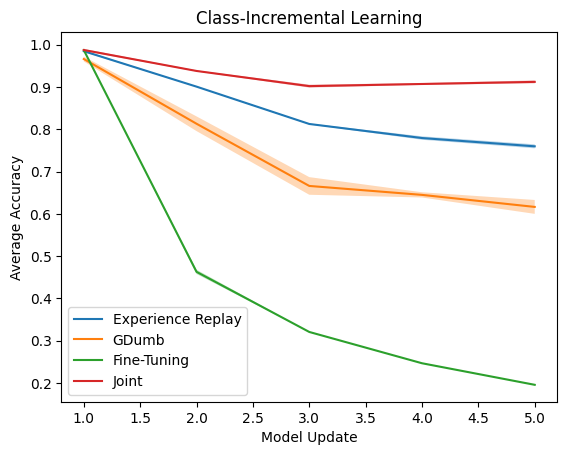

In [4]:
plt.figure(facecolor="w")
for label, results in final_results.items():
    x = np.arange(1, len(results["mean"]) + 1)
    plt.plot(x, results["mean"], label=UPDATER_LABELS[label])
    plt.fill_between(x, results["mean"] - results["std"], results["mean"] + results["std"], alpha=0.3)
plt.xlabel("Model Update")
plt.ylabel("Average Accuracy")
plt.title("Class-Incremental Learning")
plt.legend()

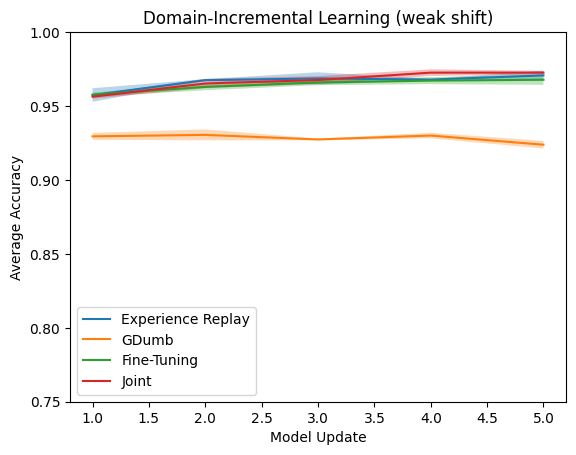

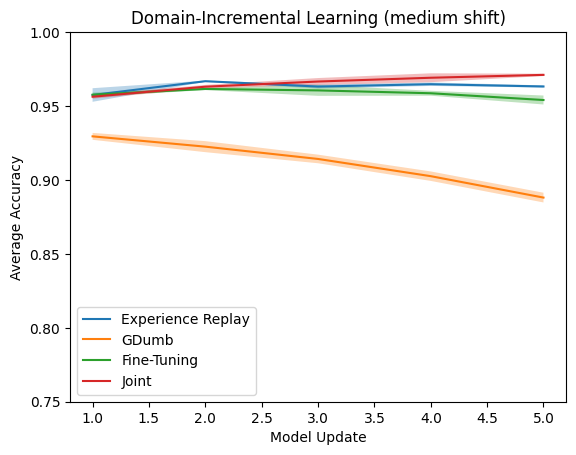

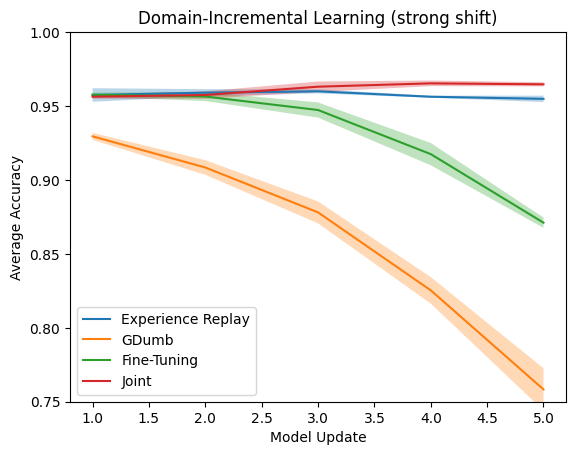

In [19]:
for max_degree, noise in zip([5, 20, 45], ["weak", "medium", "strong"]):
    plt.figure(facecolor="w")
    for label, results in final_results[max_degree].items():
        x = np.arange(1, len(results["mean"]) + 1)
        plt.plot(x, results["mean"], label=UPDATER_LABELS[label])
        plt.fill_between(x, results["mean"] - results["std"], results["mean"] + results["std"], alpha=0.3)
    plt.xlabel("Model Update")
    plt.ylabel("Average Accuracy")
    plt.ylim(0.75, 1)
    plt.title(f"Domain-Incremental Learning ({noise} shift)")
    plt.legend()

# IID

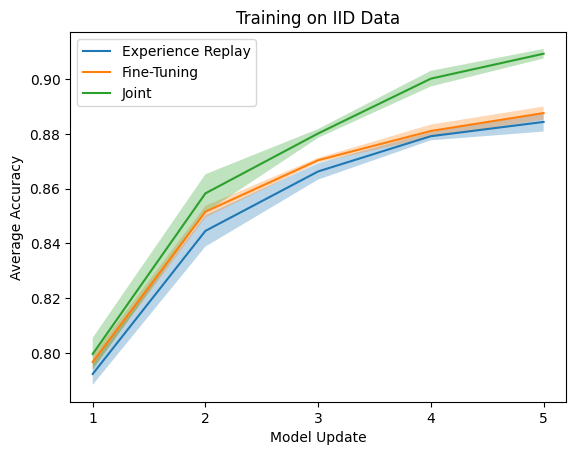

In [5]:
plt.figure(facecolor="w")
for label, results in final_results.items():
    x = [str(int(x)) for x in np.arange(1, len(results["mean"]) + 1)]
    plt.plot(x, results["mean"], label=UPDATER_LABELS[label])
    plt.fill_between(x, results["mean"] - results["std"], results["mean"] + results["std"], alpha=0.3)
plt.xlabel("Model Update")
plt.ylabel("Average Accuracy")
plt.title("Training on IID Data")
plt.legend()
plt.savefig("figs/iid_avg_acc.pdf", bbox_inches="tight")

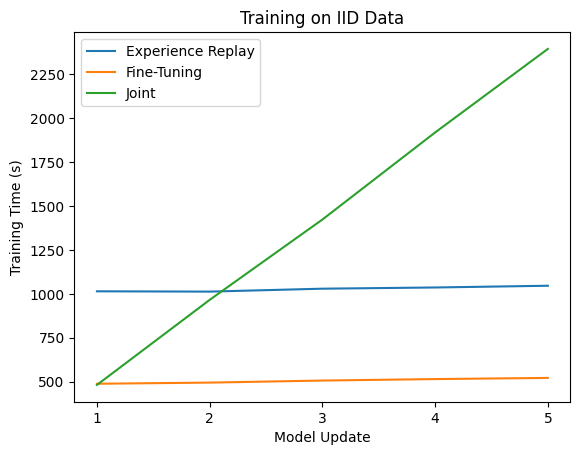

In [6]:
plt.figure(facecolor="w")
for label, results in final_results.items():
    x = [str(int(x)) for x in np.arange(1, len(results["mean"]) + 1)]
    mean_time = [results["mean_time"][0]]
    for i in range(1, len(results["mean_time"])):
        mean_time.append(results["mean_time"][i] - results["mean_time"][i-1])
    plt.plot(x, mean_time, label=UPDATER_LABELS[label])
plt.xlabel("Model Update")
plt.ylabel("Training Time (s)")
plt.title("Training on IID Data")
plt.legend()
plt.savefig("figs/iid_time.pdf", bbox_inches="tight")